TODO:
~~Use numpy instead of 2d list~~
~~Clean up code~~
~~Finish enviorment and move code to seperate python file instead of juypter notebook (conflict errors with jupyter can be horrid)~~
~~Create Q-Learning agent (NO DeepL)~~
~~Create DeepL Agent (DQN)~~
~~Add experience replay~~
~~Adjust Q network~~
Add following to data tracking
    - Steps
    - Average Reward
    - Lines Cleared (Total)
Adjust Reward System, (Add more and adjust weights https://github.com/YuhanXiaoJY/Implementation-of-El-Tetris)
(WELLS, COLUMN TRANSITION, ROW TRANSITION, )
Change Tetris to work on instant steps. (Model chooses column and rotation -> instant hard drop)
Adjust training values until satisfactory

MAYBE?
Train with limited action to suggest better placement (more 4 line clears)
Decrease board size
Train with limited pieces
Prioritized experience replay https://arxiv.org/pdf/1511.05952 

FUTURE TODO(?)
Increase board size
Add different agent
Try different networks (actor critic, etc)
Compete against human
Work with time instead of step

In [18]:
pip install --upgrade tensorflow-probability

Note: you may need to restart the kernel to use updated packages.


In [19]:
# Imports
# pyright: ignore[reportMissingImports]

import os
import sys
# Keep using keras-2 (tf-keras) rather than keras-3 (keras).
os.environ['TF_USE_LEGACY_KERAS'] = '1'
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import abc
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np

from tf_agents.specs import array_spec
from tf_agents.specs import tensor_spec
from tf_agents.networks import network

from tf_agents.policies import py_policy
from tf_agents.policies import random_py_policy
from tf_agents.policies import scripted_py_policy

from tf_agents.policies import tf_policy
from tf_agents.policies import random_tf_policy
from tf_agents.policies import actor_policy
from tf_agents.policies import q_policy
from tf_agents.policies import greedy_policy

from tf_agents.trajectories import time_step as ts

from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

from tf_agents.environments import py_environment
from tf_agents.environments import tf_environment
from tf_agents.environments import tf_py_environment
from tf_agents.environments import utils
from tf_agents.specs import array_spec
from tf_agents.environments import wrappers
from tf_agents.environments import suite_gym
from tf_agents.trajectories import time_step as ts

In [ ]:
"""
Tetris TF-Agents PyEnvironment Wrapper
Wraps the Step Tetris implementation for use with TensorFlow Q-Learning (DQN).
"""

import numpy as np
import tensorflow as tf

from tf_agents.environments import py_environment
from tf_agents.specs import array_spec
from tf_agents.trajectories import time_step as ts

from tetris import Tetris


# Reward / feature helpers
def _count_holes(board: np.ndarray) -> int:
    """
    A hole is any empty tile that has at least one filled tile above
    it in the same column.
    """
    holes = 0
    rows, cols = board.shape

    for col in range(cols):
        block_found = False
        for row in range(rows):
            if board[row, col] == 1:
                block_found = True
            elif block_found:
                holes += 1
    return holes


def _aggregate_height(board: np.ndarray) -> int:
    """Sum of the height of each column."""
    rows, cols = board.shape
    total = 0

    for col in range(cols):
        for row in range(rows):
            if board[row, col] == 1:
                total += rows - row  # height from bottom
                break
    return total


def _bumpiness(board: np.ndarray) -> int:
    """Sum of absolute height differences between adjacent columns."""
    rows, cols = board.shape
    heights = []

    for col in range(cols):
        h = 0
        for row in range(rows):
            if board[row, col] == 1:
                h = rows - row
                break
        heights.append(h)
    return sum(abs(heights[i] - heights[i + 1]) for i in range(cols - 1))

def _row_fullness(board: np.ndarray) -> float:
    """Sum of (filled_cells / cols)^2 per row, rewards nearly-full rows disproportionately."""
    cols = board.shape[1]
    return float(np.sum((board.sum(axis=1) / cols) ** 2))

# Environment

# Maps possible actions to integers
ACTION_MAP = {
    0: "LEFT",
    1: "RIGHT",
    2: "COUNTERCLOCKWISE",
    3: "CLOCKWISE",
    4: "NOOP",
    5: "HARD_DROP",
}

# How many extra features are appended after the flattened board
# [next_piece_id (1), lines_cleared_this_step (1)]
_EXTRA_FEATURES = 2


class TetrisEnv(py_environment.PyEnvironment):
    """
    TensorFlow PyEnvironment wrapper for the Tetris implementation.

    Observation
    -----------
    A flat float32 vector of length (rows * cols + _EXTRA_FEATURES):
        - Flattened board  (Binary 0/1 filled/unfilled)
        - next_piece id    (normalised to 0-1)
        - lines_cleared_this_step (raw int cast to float)

    Action
    ------
    Discrete integer in [0, 5] mapping to LEFT / RIGHT / CCW / CW / NOOP / HARD_DROP.

    Reward
    ------
    Reward attemps to encourage staying alive and "Good" placement.
    
    Negative
        - Bumpiness (The difference between heights of columns)
        - Aggreagte Height (The total height)
        - Holes (Blank tiles with above tile filled)

    Positive
        - Fullness (Reward for having rows almost filled, rewards more based on fill)
        - Lines Cleared (Clearing lines gives exponential reward)
        - Time Alive (Slow scaling reward for living)

    Episode termination
    -------------------
    The episode ends when the Tetris game is over.

    """

    # Reward shaping weights
    w_height   = 2.0
    w_holes    = 0.5
    w_bumpiness    = 0.4
    w_lines    = 20.0
    w_time_alive = 0.4
    w_fullness = 1.0

    def __init__(self, rows: int = 14, cols: int = 8, render: bool = False):
        super().__init__()

        self._rows = rows
        self._cols = cols
        self._render = render
        self._curriculum_level = 4

        obs_size = rows * cols + cols
        self._observation_spec = array_spec.BoundedArraySpec(
            shape=(obs_size,),
            dtype=np.float32,
            minimum=0.0,
            maximum=float(max(rows, cols, 6)),  # generous upper bound
            name="observation",
        )

        # Action Spec
        self._action_spec = array_spec.BoundedArraySpec(
            shape=(),
            dtype=np.int32,
            minimum=0,
            maximum=cols * 4 - 1,
            name="action",
        )

        # Internal game instance
        self._game = Tetris(_rows=rows, _cols=cols, _render=render)
        self._episode_ended = False
        self._prev_score = 0

    # PyEnvironment interface

    def observation_spec(self):
        return self._observation_spec

    def action_spec(self):
        return self._action_spec

    def _reset(self):
        self._game.reset()

        if self._curriculum_level > 0:
            self._game.prefill_board(self._curriculum_level)

        self._episode_ended = False
        self._prev_score = 0
        return ts.restart(self._get_observation())

    def _step(self, action):
        if self._episode_ended:
            # Auto reset at the start of a new episode
            return self._reset()

        score_before = self._game.score
        pieces_before = self._game.pieces_placed
        # board_before = np.copy(self._game.board)

        # Get action from map and do step
        col = action // 4
        rotation = action % 4
        self._game.step_col(col, rotation)

        # Check for game over
        score_after = self._game.score
        game_over = not self._game.is_alive()

        # Lines cleared this step (score delta, clamped)
        score_this_step = max(0, score_after - score_before)

        if (self._game.pieces_placed > 10000):
            game_over = True

        # Reward
        board_now = self._game.board
        reward = (
            self.w_lines      * (score_this_step ** 2)
            # + self.w_fullness * _row_fullness(board_now)   
            # - self.w_height   * _aggregate_height(board_now)
            # - self.w_holes    * _count_holes(board_now)
            # - self.w_bumpiness * _bumpiness(board_now)
        )
        reward += (self.w_time_alive * self._game.get_pieces_placed()) ** 2  # tiny step bonus only

        obs = self._get_observation(lines_cleared=score_this_step)

        if game_over:
            reward -= 500.0
            print(f"Pieces Placed: {self._game.get_pieces_placed()}")
            self._game.reset()
            self._episode_ended = True
            return ts.termination(obs, reward=float(reward))
        else:
            return ts.transition(obs, reward=float(reward), discount=0.99)

    # Helpers functions
    def _get_observation(self, lines_cleared: int = 0) -> np.ndarray:
        """Build the flat observation vector and add extra features."""
        flat_board = self._game.get_board_copy().flatten().astype(np.float32)
        extras = np.array(
            [
                self._game.next_piece / 6.0,   # normalised piece id [0,1]
                float(lines_cleared),
            ],
            dtype=np.float32,
        )
        extra_fill = np.zeros(self._cols - 2, dtype=np.float32)
        return np.concatenate([flat_board, extras, extra_fill])

    def render(self):
        self._game._render()

    def reduce_curriculum(self):
        if (self._curriculum_level > 0):
            self._curriculum_level -= 1


In [ ]:
"""
Tetris DQN Training Loop
========================

Trains a DQN agent on TetrisEnv, periodically saves the policy and
writes training metrics to both a CSV log and TensorBoard summaries.

Saves training states in checkpoints mode in saved_policy
"""

import csv
import datetime
from pathlib import Path

import numpy as np
import tensorflow as tf

from tf_agents.agents.dqn import dqn_agent
from tf_agents.environments import tf_py_environment
from tf_agents.networks import sequential
from tf_agents.replay_buffers import tf_uniform_replay_buffer
from tf_agents.policies import policy_saver, random_tf_policy
from tf_agents.utils import common
from tf_agents.trajectories import trajectory

# Config

CONFIG = {
    # Environment
    "rows": 14,
    "cols": 8,

    # Training schedule
    "iterations": 500_000,
    "initial_collect": 10_000,
    "collect_per_iter": 1,

    # Replay buffer
    "buffer_capacity": 50_000,
    "batch_size": 64,

    # Network
    "fc_layers": (256, 128, 64),
    "conv_layers": [(32, (3, 3), 1), (64, (3, 3), 1),],

    # Agent
    "learning_rate": 2.5e-4,
    "gamma": 0.99,  
    "epsilon_start": 1.0,
    "epsilon_end": 0.01,
    "epsilon_decay": 1_000_000,
    "target_update_period": 500,

    # Logging
    "log_interval": 200,
    "eval_interval": 10_000,
    "eval_episodes": 5,
    "save_interval": 10_000,
    "checkpoint_dir": "checkpoints_4",
    "policy_dir": "saved_policy_4",
    "log_dir": "logs",
    "log_name": "dqn_training_log_4.csv"
}


# Helpers fucntions
class _Cfg:
    """Wraps a plain dict so values are accessible as attributes."""
    def __init__(self, d):
        self.__dict__.update(d)

# QNET, Convuluted layers and fully connected layers
def build_q_network(obs_spec, action_spec, fc_layers, conv_layers):
    num_actions = action_spec.maximum - action_spec.minimum + 1
    layers = []

    # reshape for conv
    layers.append(tf.keras.layers.Reshape((15, 8, 1)))  

    # Add conv layer
    for filters, kernel_size, stride in conv_layers:
        layers.append(
            tf.keras.layers.Conv2D(
                filters=filters,
                kernel_size=kernel_size,
                strides=stride,
                padding="same",
                activation="relu",
                kernel_initializer=tf.keras.initializers.VarianceScaling(
                    scale=2.0, mode="fan_in", distribution="truncated_normal",
                ),
            )
        )

    layers.append(tf.keras.layers.Flatten())
    
    # Add fc layers
    for units in fc_layers:
        layers.append(
            tf.keras.layers.Dense(
                units,
                activation="relu",
                kernel_initializer=tf.keras.initializers.VarianceScaling(
                    scale=2.0, mode="fan_in", distribution="truncated_normal"
                ),
            )
        )
    layers.append(
        tf.keras.layers.Dense(
            num_actions,
            activation=None,
            kernel_initializer=tf.keras.initializers.RandomUniform(
                minval=-0.03, maxval=0.03
            ),
        )
    )
    return sequential.Sequential(layers)


# Get steps for ReplayBuffer
def collect_step(env, policy, buffer):
    time_step = env.current_time_step()
    action_step = policy.action(time_step)
    next_time_step = env.step(action_step.action)
    traj = trajectory.from_transition(time_step, action_step, next_time_step)
    buffer.add_batch(traj)

# Run an evaluation and record values
def run_eval(eval_env, policy, num_episodes):
    total_rewards = []
    total_pieces  = []
    total_scores  = []

    for _ in range(num_episodes):
        time_step  = eval_env.reset()
        ep_reward  = 0.0
        py_env = eval_env.pyenv.envs[0]

        while not time_step.is_last():
            action_step = policy.action(time_step)
            time_step   = eval_env.step(action_step.action)
            ep_reward  += float(time_step.reward[0])
            pieces_placed = py_env._game.get_pieces_placed()
            

        total_rewards.append(ep_reward)

        # Pull stats directly from the wrapped PyEnvironment
        
        total_pieces.append(pieces_placed)
        total_scores.append(py_env._game.score)

    return (
        float(np.mean(total_rewards)),
        float(np.mean(total_pieces)),
        float(np.mean(total_scores)),
    )


"""
DQN Training Loop

"""
def train(config: dict = None):

    cfg = _Cfg(config if config is not None else CONFIG)

    print("\n=== Tetris DQN Training ===")
    print(f"Started: {datetime.datetime.now():%Y-%m-%d %H:%M:%S}\n")

    # Environments
    train_py_env = TetrisEnv()
    eval_py_env  = TetrisEnv()
    train_env    = tf_py_environment.TFPyEnvironment(train_py_env)
    eval_env     = tf_py_environment.TFPyEnvironment(eval_py_env)

    obs_spec    = train_env.observation_spec()
    action_spec = train_env.action_spec()

    # Q-Network and Agent
    q_net = build_q_network(obs_spec, action_spec, cfg.fc_layers, cfg.conv_layers)
    train_step_counter = tf.Variable(0, trainable=False, dtype=tf.int64)

    # Growth Rate
    epsilon = tf.compat.v1.train.polynomial_decay(
        learning_rate=cfg.epsilon_start,
        global_step=train_step_counter,
        decay_steps=cfg.epsilon_decay,
        end_learning_rate=cfg.epsilon_end,
    )

    # DDQN Agent
    agent = dqn_agent.DdqnAgent(
        train_env.time_step_spec(),
        action_spec,
        q_network=q_net,
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg.learning_rate),
        td_errors_loss_fn=common.element_wise_squared_loss,
        epsilon_greedy=epsilon,
        target_update_period=cfg.target_update_period,
        gamma=cfg.gamma,
        train_step_counter=train_step_counter,
    )
    agent.initialize()

    # Replay buffer
    replay_buffer = tf_uniform_replay_buffer.TFUniformReplayBuffer(
        data_spec=agent.collect_data_spec,
        batch_size=train_env.batch_size,
        max_length=cfg.buffer_capacity,
    )
    dataset  = replay_buffer.as_dataset(
        num_parallel_calls=3, sample_batch_size=cfg.batch_size, num_steps=2
    ).prefetch(3)
    iterator = iter(dataset)

    # Random Policy for buffer
    random_policy  = random_tf_policy.RandomTFPolicy(
        train_env.time_step_spec(), action_spec
    )
    collect_policy = agent.collect_policy
    eval_policy    = agent.policy

    # Checkpointer
    checkpoint_dir = Path(cfg.checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    checkpointer = common.Checkpointer(
        ckpt_dir=str(checkpoint_dir),
        max_to_keep=3,
        agent=agent,
        policy=agent.policy,
        replay_buffer=replay_buffer,
        global_step=train_step_counter,
    )
    checkpointer.initialize_or_restore()
    print(f"Checkpoint dir : {checkpoint_dir.resolve()}")

    # Policy saver
    policy_dir = Path(cfg.policy_dir)
    policy_dir.mkdir(parents=True, exist_ok=True)
    print(f"Policy dir     : {policy_dir.resolve()}")

    # CSV and TensorBoard logging
    log_dir = Path(cfg.log_dir)
    log_name = Path(cfg.log_name)
    (log_dir / "tb").mkdir(parents=True, exist_ok=True)
    summary_writer = tf.summary.create_file_writer(str(log_dir / "tb"))

    csv_path   = log_dir / log_name
    csv_exists = csv_path.exists()
    csv_file   = open(csv_path, "a", newline="")
    csv_writer = csv.DictWriter(
    csv_file,
        fieldnames=[
            "iteration", "loss", "epsilon",
            "eval_reward", "avg_pieces_placed", "avg_score",   # ← added
            "timestamp",
        ],
    )
    if not csv_exists:
        csv_writer.writeheader()

    print(f"CSV log        : {csv_path.resolve()}")
    print(f"TensorBoard    : {(log_dir / 'tb').resolve()}\n")

    # Initial random collection
    start_step = int(train_step_counter.numpy())
    if start_step == 0:
        print(f"Collecting {cfg.initial_collect} random steps …")
        train_env.reset()
        for _ in range(cfg.initial_collect):
            collect_step(train_env, random_policy, replay_buffer)
        print("Initial collection done.\n")
    else:
        print(f"Resuming from step {start_step}.\n")

    # Training loop
    train_env.reset()
    loss_history = []

    for _ in range(cfg.iterations):
        for _ in range(cfg.collect_per_iter):
            collect_step(train_env, collect_policy, replay_buffer)

        experience, _ = next(iterator)
        train_loss = agent.train(experience).loss
        step = int(train_step_counter.numpy())
        loss_history.append(float(train_loss))

        if step % cfg.log_interval == 0:
            avg_loss = float(np.mean(loss_history[-cfg.log_interval:]))
            eps_val  = float(epsilon())
            print(f"[{step:>7}]  loss={avg_loss:.4f}  ε={eps_val:.3f}")
            with summary_writer.as_default():
                tf.summary.scalar("train/loss",    avg_loss, step=step)
                tf.summary.scalar("train/epsilon", eps_val,  step=step)

        # Run eval and log
        if step % cfg.eval_interval == 0:

            eval_reward, avg_pieces, avg_score = run_eval(
                eval_env, eval_policy, cfg.eval_episodes)

            if eval_reward > 1000:
                train_env.reduce_curriculum()

            print(
                f"[{step:>7}]  *** eval reward={eval_reward:.2f} | "
                f"pieces={avg_pieces:.1f} | score={avg_score:.2f} ***")

            with summary_writer.as_default():
                tf.summary.scalar("eval/mean_reward",        eval_reward, step=step)
                tf.summary.scalar("eval/avg_pieces_placed",  avg_pieces,  step=step)   
                tf.summary.scalar("eval/avg_score",          avg_score,   step=step)   

            csv_writer.writerow({
                "iteration":        step,
                "loss":             f"{float(np.mean(loss_history[-cfg.eval_interval:])):.6f}",
                "epsilon":          f"{float(epsilon()):.4f}",
                "eval_reward":      f"{eval_reward:.4f}",
                "avg_pieces_placed": f"{avg_pieces:.2f}",   
                "avg_score":        f"{avg_score:.2f}",     
                "timestamp":        datetime.datetime.now().isoformat(),
            })
            csv_file.flush()

        if step % cfg.save_interval == 0 and step > 0:
            checkpointer.save(global_step=train_step_counter)
            tf.saved_model.save(eval_policy, str(policy_dir))
            print(f"[{step:>7}]  Saved checkpoint + policy.")

    # Final save
    checkpointer.save(global_step=train_step_counter)
    tf.saved_model.save(eval_policy, str(policy_dir))
    csv_file.close()

    final_reward, final_pieces, final_score = run_eval(   # ← unpack 3 values
        eval_env, eval_policy, cfg.eval_episodes * 2
    )
    print(
        f"\nTraining complete — "
        f"reward={final_reward:.2f} | pieces={final_pieces:.1f} | score={final_score:.2f}"
    )
    print(f"Policy saved to : {policy_dir.resolve()}")


In [22]:
train(CONFIG)


=== Tetris DQN Training ===
Started: 2026-04-17 00:14:25

Checkpoint dir : /home/muki/CSP/TensorTetris/checkpoints_4
Policy dir     : /home/muki/CSP/TensorTetris/saved_policy_4
CSV log        : /home/muki/CSP/TensorTetris/logs/dqn_training_log_4.csv
TensorBoard    : /home/muki/CSP/TensorTetris/logs/tb

Resuming from step 710000.

Pieces Placed: 9
Pieces Placed: 10
Pieces Placed: 8
Pieces Placed: 9
Pieces Placed: 13
Pieces Placed: 4
Pieces Placed: 12
Pieces Placed: 17
Pieces Placed: 10
Pieces Placed: 10
Pieces Placed: 8
Pieces Placed: 11
Pieces Placed: 10
Pieces Placed: 13
Pieces Placed: 17
Pieces Placed: 11
[ 710200]  loss=23524.1238  ε=0.297
Pieces Placed: 17
Pieces Placed: 15
Pieces Placed: 10
Pieces Placed: 7
Pieces Placed: 13
Pieces Placed: 10
Pieces Placed: 13
Pieces Placed: 9
Pieces Placed: 4
Pieces Placed: 9
Pieces Placed: 10
Pieces Placed: 9
Pieces Placed: 11
Pieces Placed: 10
Pieces Placed: 10
Pieces Placed: 10
Pieces Placed: 15
[ 710400]  loss=21154.0412  ε=0.297
Pieces Plac

UnboundLocalError: cannot access local variable 'py_env' where it is not associated with a value

In [ ]:
'''
Do a single run 
'''

from tf_agents.agents.dqn import dqn_agent
from tf_agents.environments import tf_py_environment
from tf_agents.utils import common
import tensorflow as tf

# Rebuild the env + agent 
env = tf_py_environment.TFPyEnvironment(TetrisEnv(rows=14, cols=8, render=True))
q_net = build_q_network(env.observation_spec(), env.action_spec(), (256, 128, 64), [(32, (3, 3), 1), (64, (3, 3), 1),])
train_step_counter = tf.Variable(0, trainable=False, dtype=tf.int64)

agent = dqn_agent.DqnAgent(
    env.time_step_spec(),
    env.action_spec(),
    q_network=q_net,
    optimizer=tf.keras.optimizers.Adam(1e-3),
    td_errors_loss_fn=common.element_wise_squared_loss,
    train_step_counter=train_step_counter,
)
agent.initialize()

# Restore weights from checkpoint
checkpointer = common.Checkpointer(
    ckpt_dir="checkpoints_5",
    agent=agent,
    global_step=train_step_counter,
)
checkpointer.initialize_or_restore()
print(f"Restored from step {int(train_step_counter.numpy())}")

# Run eval
mean_reward = run_eval(env, agent.policy, num_episodes=1)
# print(f"Mean reward: {mean_reward:.2f}")

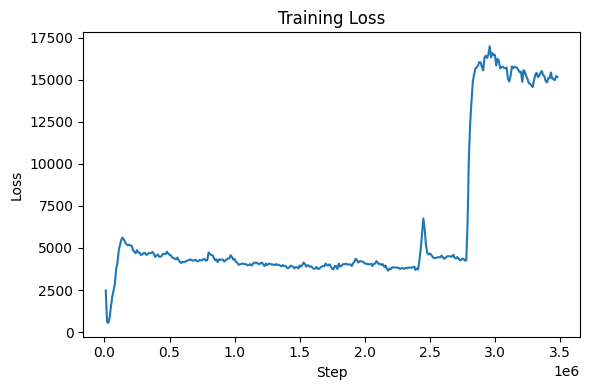

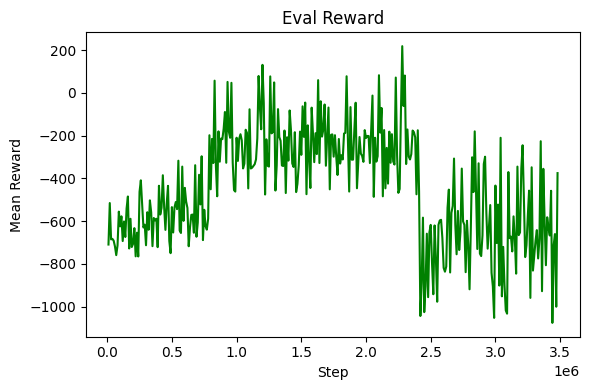

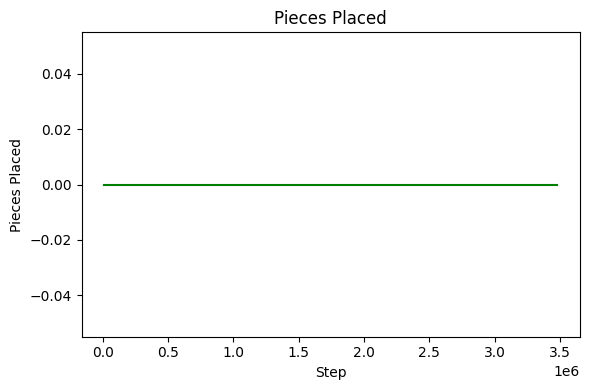

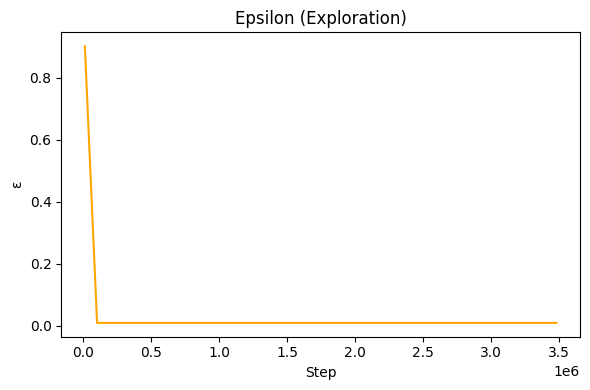

In [ ]:
""" Create Graphs """

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("logs/dqn_training_log_3.csv")

# Loss
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df["iteration"], df["loss"])
ax.set_title("Training Loss")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
plt.tight_layout()
plt.savefig("loss2.png")
plt.show()

# Eval reward
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df["iteration"], df["eval_reward"], color="green")
ax.set_title("Eval Reward")
ax.set_xlabel("Step")
ax.set_ylabel("Mean Reward")
plt.tight_layout()
plt.savefig("reward2.png")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df["iteration"], df["avg_pieces_placed"], color="green")
ax.set_title("Pieces Placed")
ax.set_xlabel("Step")
ax.set_ylabel("Pieces Placed")
plt.tight_layout()
plt.savefig("placed2.png")
plt.show()

# Epsilon decay
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df["iteration"], df["epsilon"], color="orange")
ax.set_title("Epsilon (Exploration)")
ax.set_xlabel("Step")
ax.set_ylabel("ε")
plt.tight_layout()
plt.savefig("exploration2.png")
plt.show()